In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [19]:
df = pd.read_csv("./data_ts/daily-minimum-temperatures-in-me.csv").head(200)

In [20]:
df

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8
...,...,...
195,7/15/1981,7.2
196,7/16/1981,6.3
197,7/17/1981,8.8
198,7/18/1981,5


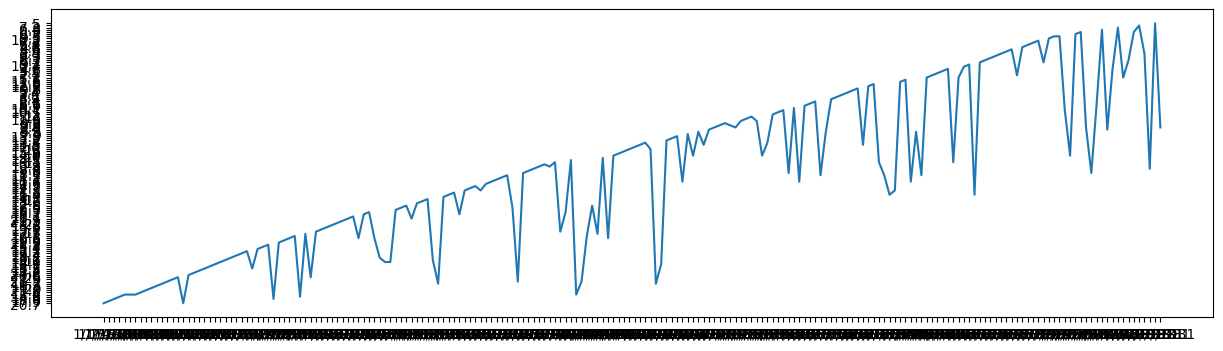

In [21]:
plt.figure(figsize=(15, 4))
plt.plot(df["Date"], df["Daily minimum temperatures"])

In [22]:
prediction_len = 1
context_len = 5

In [25]:
ts = df["Daily minimum temperatures"]

In [27]:
ts.head(10)

0    20.7
1    17.9
2    18.8
3    14.6
4    15.8
5    15.8
6    15.8
7    17.4
8    21.8
9      20
Name: Daily minimum temperatures, dtype: object

In [49]:
xData = []
yData = []

for i in range(len(ts)-context_len):
    x = ts.iloc[i:i+context_len].values.astype(float)
    y = ts.iloc[i+context_len:i+context_len+prediction_len].values.astype(float)
    xData.append(x)
    yData.append(y)

In [52]:
xData = np.array(xData)
yData = np.array(yData)

In [53]:
xData.shape

(195, 5)

In [54]:
yData.shape

(195, 1)

In [55]:
from tensorflow.keras import layers
import tensorflow as tf

2025-07-16 22:19:59.044855: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [65]:
input_layers = tf.keras.Input(shape=(xData.shape[1:]))

model = layers.Dense(16, activation="elu")(input_layers)
model = layers.Dropout(0.3)(model)

model = layers.Dense(12, activation="elu")(model)
model = layers.Dropout(0.3)(model)

model = layers.Dense(8, activation="elu")(model)
model = layers.Dropout(0.3)(model)

model = layers.Dense(1,  activation="linear")(model)

model = tf.keras.Model(input_layers, model)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 12)             │           204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413 (1.61 KB)

 Trainable params: 413 (1.61 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(optimizer="adam", loss="mse")

In [67]:
model.fit(xData, yData, epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 198.2867
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 191.1366 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 167.9421 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 161.9504 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 137.6534 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 122.3305 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 92.4819 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99.1577  
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 87.9946 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 85.2753 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 81.7903 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 81.3455 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 96.8505 
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 97.8311 
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 73.1369

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [70]:
rf = RandomForestRegressor()
rf.fit(xData, yData)
y_pred = rf.predict(xData)

/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [74]:
mean_squared_error(yData, y_pred)

0.9367564564102561